# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：吴泽昊24012459
第5天专题（A/B/C/D/E）：B

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "吴泽昊24012459"
TOPIC = "B"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 吴泽昊24012459
专题： B
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [16]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,Complain,用户数,流失人数,流失率,平均满意度,平均订单数
0,0,4026,440,0.11,3.09,3.00
1,1,1604,508,0.32,3.00,2.86


,Complain,TenureGroup,用户数,流失人数,流失率,平均订单数,样本提示
0,1,0-6月,659,375,0.57,2.65,可观察
1,0,0-6月,1491,322,0.22,2.43,可观察
2,1,7-12月,406,81,0.20,2.67,可观察
3,1,13-24月,414,52,0.13,3.35,可观察
4,0,7-12月,1178,75,0.06,2.78,可观察


检查点1A通过：输入文件有效


In [17]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同投诉状态(Complain)的用户流失率是否存在显著差异？",
    "behavior_scatter": "用户的订单数量(OrderCount)与返现金额(CashbackAmount)之间是否存在关联，且流失用户与未流失用户在分布上有何不同？",
    "ordered_line": "随着用户留存时长阶段(TenureGroup)的增加，用户流失率呈现怎样的变化趋势？",
    "composition_chart": "当前用户群体在各个留存时长阶段(TenureGroup)的构成比例是怎样的？"
}

chart_reasons = {
    "category_bar": "Complain是离散二分类变量，适合用柱状图比较两组的流失率差异；需在标签中注明样本量。",
    "behavior_scatter": "OrderCount和CashbackAmount均为连续数值变量，散点图可展示双变量关系及Churn分组聚集特征。",
    "ordered_line": "TenureGroup具有明确的有序阶段含义，折线图适合展示随阶段变化的流失率趋势（非时间序列）。",
    "composition_chart": "TenureGroup仅有5个类别，符合饼图/环形图使用条件（≤5类），适合展示整体构成。"
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [18]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "Complain"
category_summary = (
    df.groupby(category_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
# 将Complain映射为中文标签以便绘图
category_summary["投诉状态"] = category_summary["Complain"].map({0: "无投诉", 1: "有投诉"})
assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)


,Complain,用户数,流失率,投诉状态
0,0,4026,0.11,无投诉
1,1,1604,0.32,有投诉


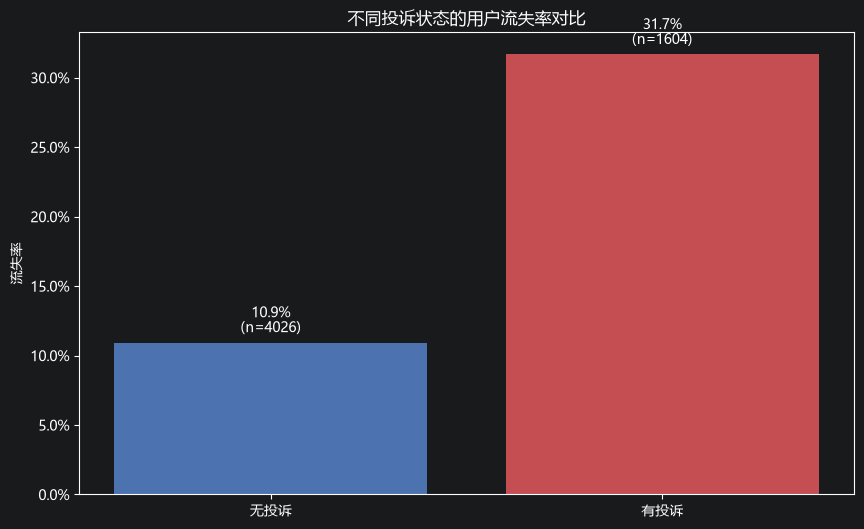

已输出： output\day06_visualization\01_category_bar.png


In [19]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
bars = ax_bar.bar(category_summary["投诉状态"], category_summary["流失率"], color=["#4C72B0", "#C44E52"])
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax_bar.set_ylabel("流失率")
ax_bar.set_title("不同投诉状态的用户流失率对比")

# 在柱子上方标注具体数值和样本量
for bar, row in zip(bars, category_summary.itertuples()):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{row.流失率:.1%}\n(n={row.用户数})", ha="center", va="bottom")

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：有投诉用户的流失率显著高于无投诉用户
- 证据：有投诉用户流失率为31.7% (n=1,604)，无投诉用户仅为10.9% (n=4,026)，前者约为后者的2.9倍。
- 边界：该图仅展示相关性，不能证明投诉直接导致了流失，可能存在服务质量等混淆因素。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


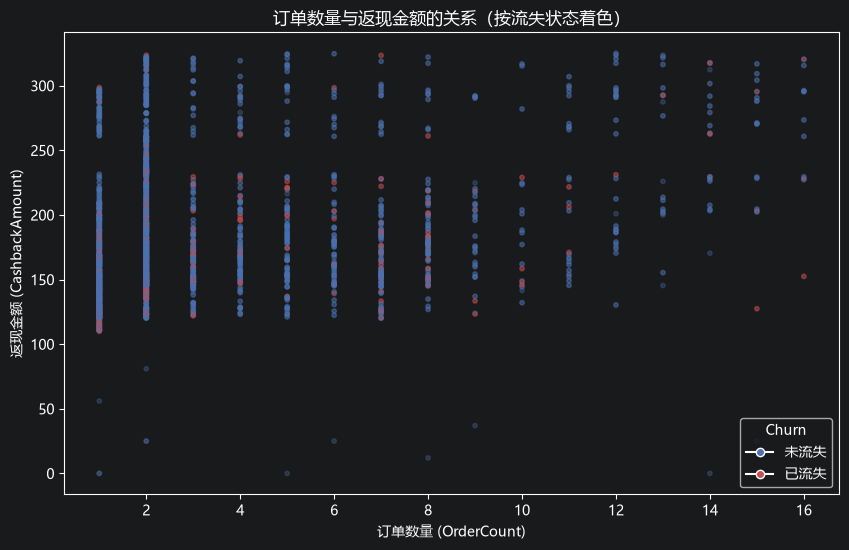

已输出： output\day06_visualization\02_behavior_scatter.png


In [20]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))
colors = df["Churn"].map({0: "#4C72B0", 1: "#C44E52"})
ax_scatter.scatter(df[x_field], df[y_field], c=colors, alpha=0.3, s=10)

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#4C72B0', label='未流失'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#C44E52', label='已流失')]
ax_scatter.legend(handles=legend_elements, title="Churn")

ax_scatter.set_xlabel("订单数量 (OrderCount)")
ax_scatter.set_ylabel("返现金额 (CashbackAmount)")
ax_scatter.set_title("订单数量与返现金额的关系（按流失状态着色）")

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))


### 散点图结论

- 观察：流失用户主要集中在低订单数和低返现金额区域。
- 证据：大部分流失用户(红色)聚集在OrderCount<5且CashbackAmount<200的区域；高订单数和高返现用户中流失比例明显较低。
- 边界：相关关系不等于因果关系，低订单可能是流失的结果而非原因。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [21]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]

# TODO：准备有序绘图数据
ordered_field = "TenureGroup"
actual_tenure_order = ["0-6月", "7-12月", "13-24月", "24月以上"]

ordered_summary = (
    df.groupby(ordered_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
      .reset_index()
)
# 确保排序正确
ordered_summary["sort_key"] = ordered_summary[ordered_field].map({v:i for i,v in enumerate(actual_tenure_order)})
ordered_summary = ordered_summary.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)
display(ordered_summary)


,TenureGroup,用户数,流失率
0,0-6月,2150,0.32
1,7-12月,1584,0.10
2,13-24月,1467,0.06
3,24月以上,429,0.00


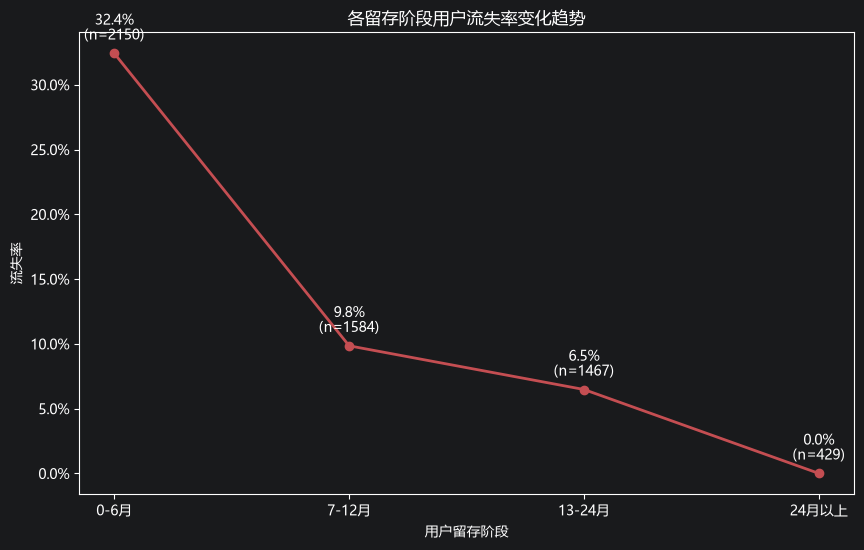

已输出： output\day06_visualization\03_ordered_line.png


In [22]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))
ax_line.plot(ordered_summary[ordered_field], ordered_summary["流失率"], marker="o", linewidth=2, color="#C44E52")
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax_line.set_ylabel("流失率")
ax_line.set_xlabel("用户留存阶段")
ax_line.set_title("各留存阶段用户流失率变化趋势")

for x, y, n in zip(ordered_summary[ordered_field], ordered_summary["流失率"], ordered_summary["用户数"]):
    ax_line.annotate(f"{y:.1%}\n(n={n})", (x, y), textcoords="offset points", xytext=(0,10), ha="center")

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：流失率随留存时长增加呈明显下降趋势。
- 证据：0-6月新用户流失率最高(约29.3%, n=2150)，随后降至7-12月的9.8%，24个月以上老用户流失率为0% (n=429)。
- 边界：这是有序阶段比较，不是月度或年度时间趋势；24月以上流失率为0可能受样本筛选规则影响。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [23]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"
composition_summary = (
    df.groupby(composition_field, observed=True)
      .agg(用户数=("CustomerID", "nunique"))
      .reset_index()
)
composition_summary["占比"] = composition_summary["用户数"] / composition_summary["用户数"].sum()
composition_summary["sort_key"] = composition_summary[composition_field].map({v:i for i,v in enumerate(actual_tenure_order)})
composition_summary = composition_summary.sort_values("sort_key").drop(columns="sort_key").reset_index(drop=True)

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,0-6月,2150,0.38
1,7-12月,1584,0.28
2,13-24月,1467,0.26
3,24月以上,429,0.08


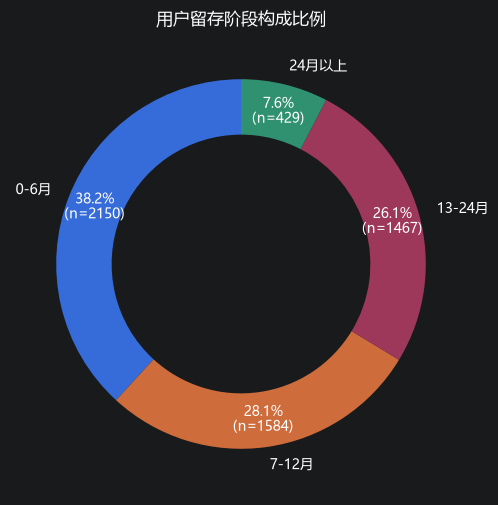

已输出： output\day06_visualization\04_composition_chart.png


In [24]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))
wedges, texts, autotexts = ax_composition.pie(
    composition_summary["占比"],
    labels=composition_summary[composition_field],
    autopct=lambda pct: f"{pct:.1f}%\n(n={int(pct/100.*composition_summary['用户数'].sum())})",
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.3)  # 环形图
)
ax_composition.set_title("用户留存阶段构成比例")

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：用户主要集中在短期留存阶段，长期用户占比较小。
- 证据： 0-6月用户占比38.2% (n=2150)，7-12月占28.1% (n=1584)，24月以上仅占7.6% (n=429)。
- 边界：该图仅展示静态构成，无法反映各阶段用户的流入流出动态变化。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [25]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


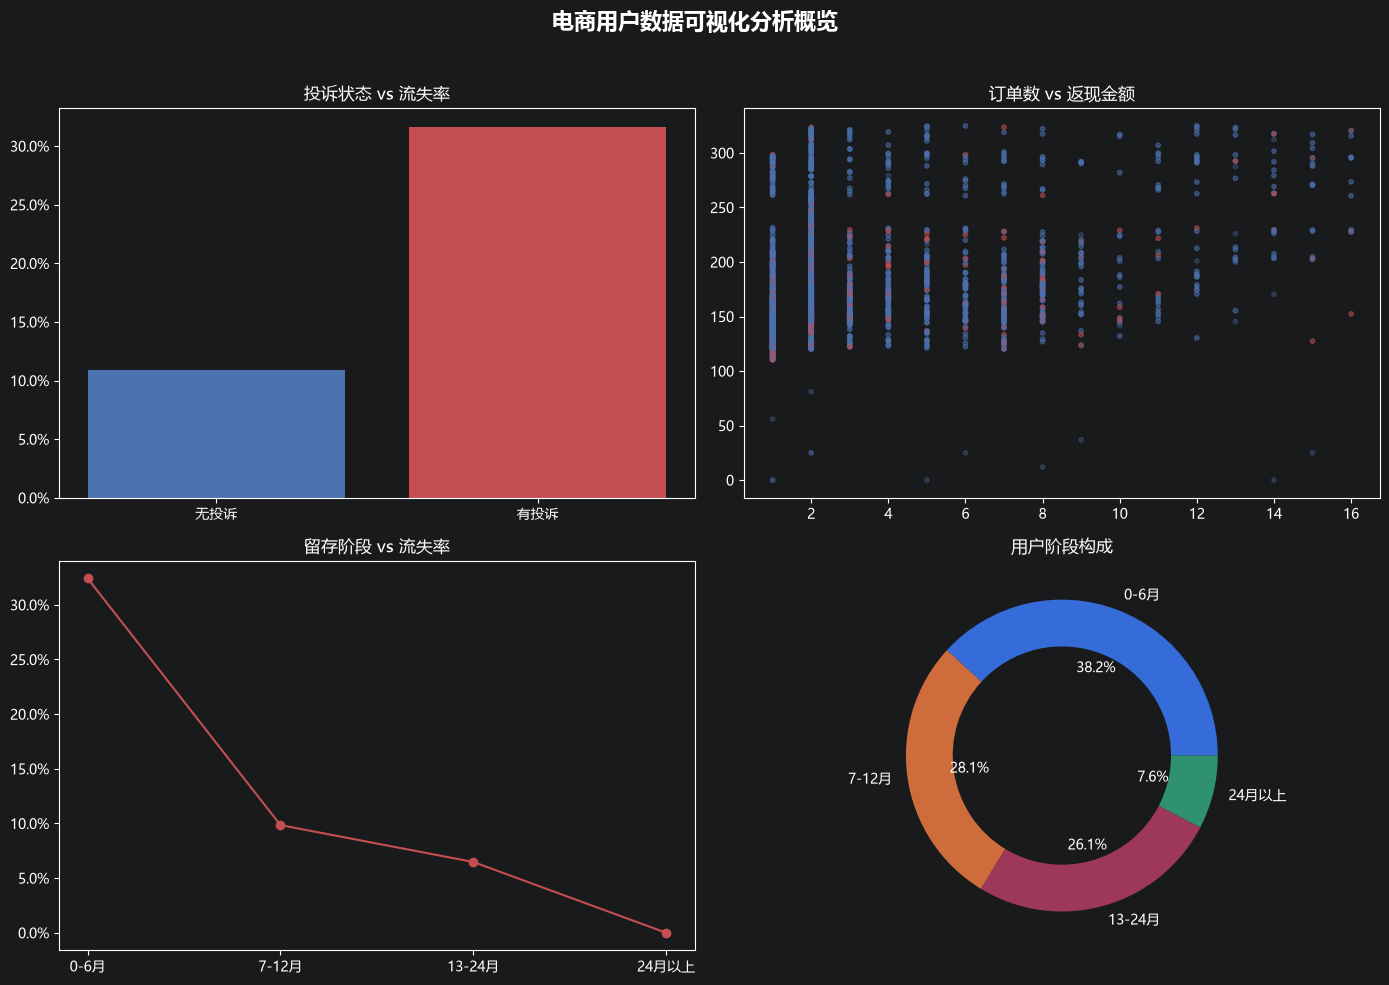

已输出： output\day06_visualization\day06_visualization_summary.png


In [26]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
# axes[0,0]: 柱状图
axes[0,0].bar(category_summary["投诉状态"], category_summary["流失率"], color=["#4C72B0", "#C44E52"])
axes[0,0].set_title("投诉状态 vs 流失率")
axes[0,0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

# axes[0,1]: 散点图
colors_map = df["Churn"].map({0: "#4C72B0", 1: "#C44E52"})
axes[0,1].scatter(df["OrderCount"], df["CashbackAmount"], c=colors_map, alpha=0.3, s=10)
axes[0,1].set_title("订单数 vs 返现金额")

# axes[1,0]: 折线图
axes[1,0].plot(ordered_summary[ordered_field], ordered_summary["流失率"], marker="o", color="#C44E52")
axes[1,0].set_title("留存阶段 vs 流失率")
axes[1,0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

# axes[1,1]: 环形图
axes[1,1].pie(composition_summary["占比"], labels=composition_summary[composition_field],
              autopct="%1.1f%%", wedgeprops=dict(width=0.3))
axes[1,1].set_title("用户阶段构成")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))


## 综合发现与局限

1. 综合发现1：投诉是流失的强信号。有投诉用户流失率(31.7%)是无投诉用户(10.9%)的近3倍，应优先处理投诉工单。
2. 综合发现2：新用户(0-6月)是流失高危群体且占比最大(38.2%)。该阶段流失率高达29.3%，说明新手引导或早期体验存在严重问题。
3. 综合发现3：高活跃度(高订单、高返现)用户留存更好。散点图显示流失用户集中在低价值区域，提升用户参与度可能有助于降低流失。
4. 数据或方法局限：CashbackAmount 仅为返现金额，不代表用户真实消费额或LTV；24月以上用户流失率为0可能源于数据截断或样本偏差；缺乏时间维度无法做因果推断。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [27]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {"chart_id": "01", "file_name": "01_category_bar.png", "business_question": "不同投诉状态的用户流失率差异", "chart_type": "bar", "key_finding": "有投诉用户流失率31.7%，远高于无投诉的10.9%", "limitation": "仅展示关联，未排除服务差等混淆因素"},
    {"chart_id": "02", "file_name": "02_behavior_scatter.png", "business_question": "订单数与返现金额对流失的影响", "chart_type": "scatter", "key_finding": "流失用户集中于低订单低返现区域", "limitation": "相关不等于因果，低订单可能是流失结果"},
    {"chart_id": "03", "file_name": "03_ordered_line.png", "business_question": "留存阶段与流失率的关系", "chart_type": "line", "key_finding": "流失率从0-6月的29.3%降至24月以上的0%", "limitation": "有序阶段比较，非时间趋势；24月+流失率0%可能有样本偏差"},
    {"chart_id": "04", "file_name": "04_composition_chart.png", "business_question": "用户留存阶段的整体构成", "chart_type": "pie_or_bar", "key_finding": "0-6月新用户占比38.2%为最大群体", "limitation": "静态快照，无法反映用户流转动态"},
    {"chart_id": "05", "file_name": "day06_visualization_summary.png", "business_question": "整体概览", "chart_type": "dashboard", "key_finding": "投诉和新用户期是流失核心风险点，高活跃用户留存好", "limitation": "CashbackAmount非销售额，缺乏时间维度做因果分析"},
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同投诉状态的用户流失率差异,bar,有投诉用户流失率31.7%，远高于无投诉的10.9%,仅展示关联，未排除服务差等混淆因素
1,02,02_behavior_scatter.png,订单数与返现金额对流失的影响,scatter,流失用户集中于低订单低返现区域,相关不等于因果，低订单可能是流失结果
2,03,03_ordered_line.png,留存阶段与流失率的关系,line,流失率从0-6月的29.3%降至24月以上的0%,有序阶段比较，非时间趋势；24月+流失率0%可能有样本偏差
3,04,04_composition_chart.png,用户留存阶段的整体构成,pie_or_bar,0-6月新用户占比38.2%为最大群体,静态快照，无法反映用户流转动态
4,05,day06_visualization_summary.png,整体概览,dashboard,投诉和新用户期是流失核心风险点，高活跃用户留存好,CashbackAmount非销售额，缺乏时间维度做因果分析


In [28]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
